## Best Optimization CV - Employer Bee Algo 2 + Onlooker Bee Algo 3

In [8]:
from Pipeline.Algorithm.ArtificialBeeColonyElmCV import ArtificialBeeColonyElmCV
from Pipeline.Global.GallstoneDataSet import GallstoneDataSet
from Pipeline.Global.GlobalSetting import GlobalSetting
from Pipeline.Global.Plotting import Plotting
from Pipeline.Methodology.ABC_Testing import abc_testing

In [9]:
fold_id = 1
mod = f"Grid_Optimization_Fold_{fold_id}"

gallstone_dataset = GallstoneDataSet()
gallstone_dataset.fetch_data_path_1()
gallstone_dataset.cross_validate_test(5)

x_train, y_train, x_test, y_test = gallstone_dataset.fold_split[fold_id]

features_size = x_train.shape[1]

In [10]:
best_lambda_config = GlobalSetting.get_config_by_type("Grid_Optimization")
best_lambda_hidden_size = best_lambda_config["Hidden_Nodes"] if best_lambda_config else None
best_lambda_lambda_value = best_lambda_config["Lambda_Value"] if best_lambda_config else None

In [11]:
abc_r_elm_cv  = ArtificialBeeColonyElmCV(
    features_size       = features_size,
    hidden_size         = best_lambda_hidden_size,
    activation_function = GlobalSetting.sigmoid             ,
    regularization_lambda=best_lambda_lambda_value           ,
    fitness_function    = GlobalSetting.evaluation_function ,
    solution_size       = GlobalSetting.solution_size       ,
    trial_limit         = GlobalSetting.trial_limit         ,
    max_iteration       = GlobalSetting.max_iteration
)
abc_r_elm_cv.employed_bee_apply_algo3()
abc_r_elm_cv.onlooker_bee_apply_algo2()

In [12]:
results_df , convergence_df , scout_df = abc_testing(abc_r_elm_cv, x_train, y_train, x_test, y_test)
results_df.describe()


Running simulation for Seed: 161...
Iteration 003 complete | Duration: 0.0767s | Scout Triggers: 4 | Best Fitness: 0.709136

Running simulation for Seed: 162...
Iteration 003 complete | Duration: 0.0753s | Scout Triggers: 4 | Best Fitness: 0.720831

Running simulation for Seed: 163...
Iteration 003 complete | Duration: 0.0614s | Scout Triggers: 4 | Best Fitness: 0.721749

Running simulation for Seed: 164...
Iteration 003 complete | Duration: 0.0637s | Scout Triggers: 3 | Best Fitness: 0.734453

Running simulation for Seed: 165...
Iteration 003 complete | Duration: 0.0775s | Scout Triggers: 4 | Best Fitness: 0.712959

Running simulation for Seed: 166...
Iteration 003 complete | Duration: 0.0835s | Scout Triggers: 4 | Best Fitness: 0.724097

Running simulation for Seed: 167...
Iteration 003 complete | Duration: 0.0809s | Scout Triggers: 4 | Best Fitness: 0.703137

Running simulation for Seed: 168...
Iteration 003 complete | Duration: 0.0833s | Scout Triggers: 4 | Best Fitness: 0.758964


,Accuracy,Precision,Recall,NPV,Specificity,F1-Score,F2-Score,Bal Accuracy,MCC,ABC_Seed
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.739583,0.843017,0.590625,0.685107,0.888542,0.693484,0.627711,0.739583,0.502963,175.500000
std,0.030523,0.047552,0.045211,0.026542,0.039086,0.038409,0.042437,0.030523,0.062988,8.803408
min,0.703125,0.760000,0.531250,0.651163,0.812500,0.641509,0.570470,0.703125,0.416333,161.000000
25%,0.718750,0.809524,0.562500,0.666667,0.875000,0.666667,0.600000,0.718750,0.460566,168.250000
50%,0.734375,0.845000,0.593750,0.675000,0.890625,0.679245,0.622958,0.734375,0.484426,175.500000
75%,0.761719,0.863636,0.625000,0.696333,0.906250,0.714206,0.653595,0.761719,0.539917,182.750000
max,0.828125,0.947368,0.718750,0.769231,0.968750,0.807018,0.751634,0.828125,0.672538,190.000000


[I/O Trace] Figure exported successfully: ../../Storage/Figure\ABC_Telemetry_Grid_Optimization_Fold_1_MCC.png


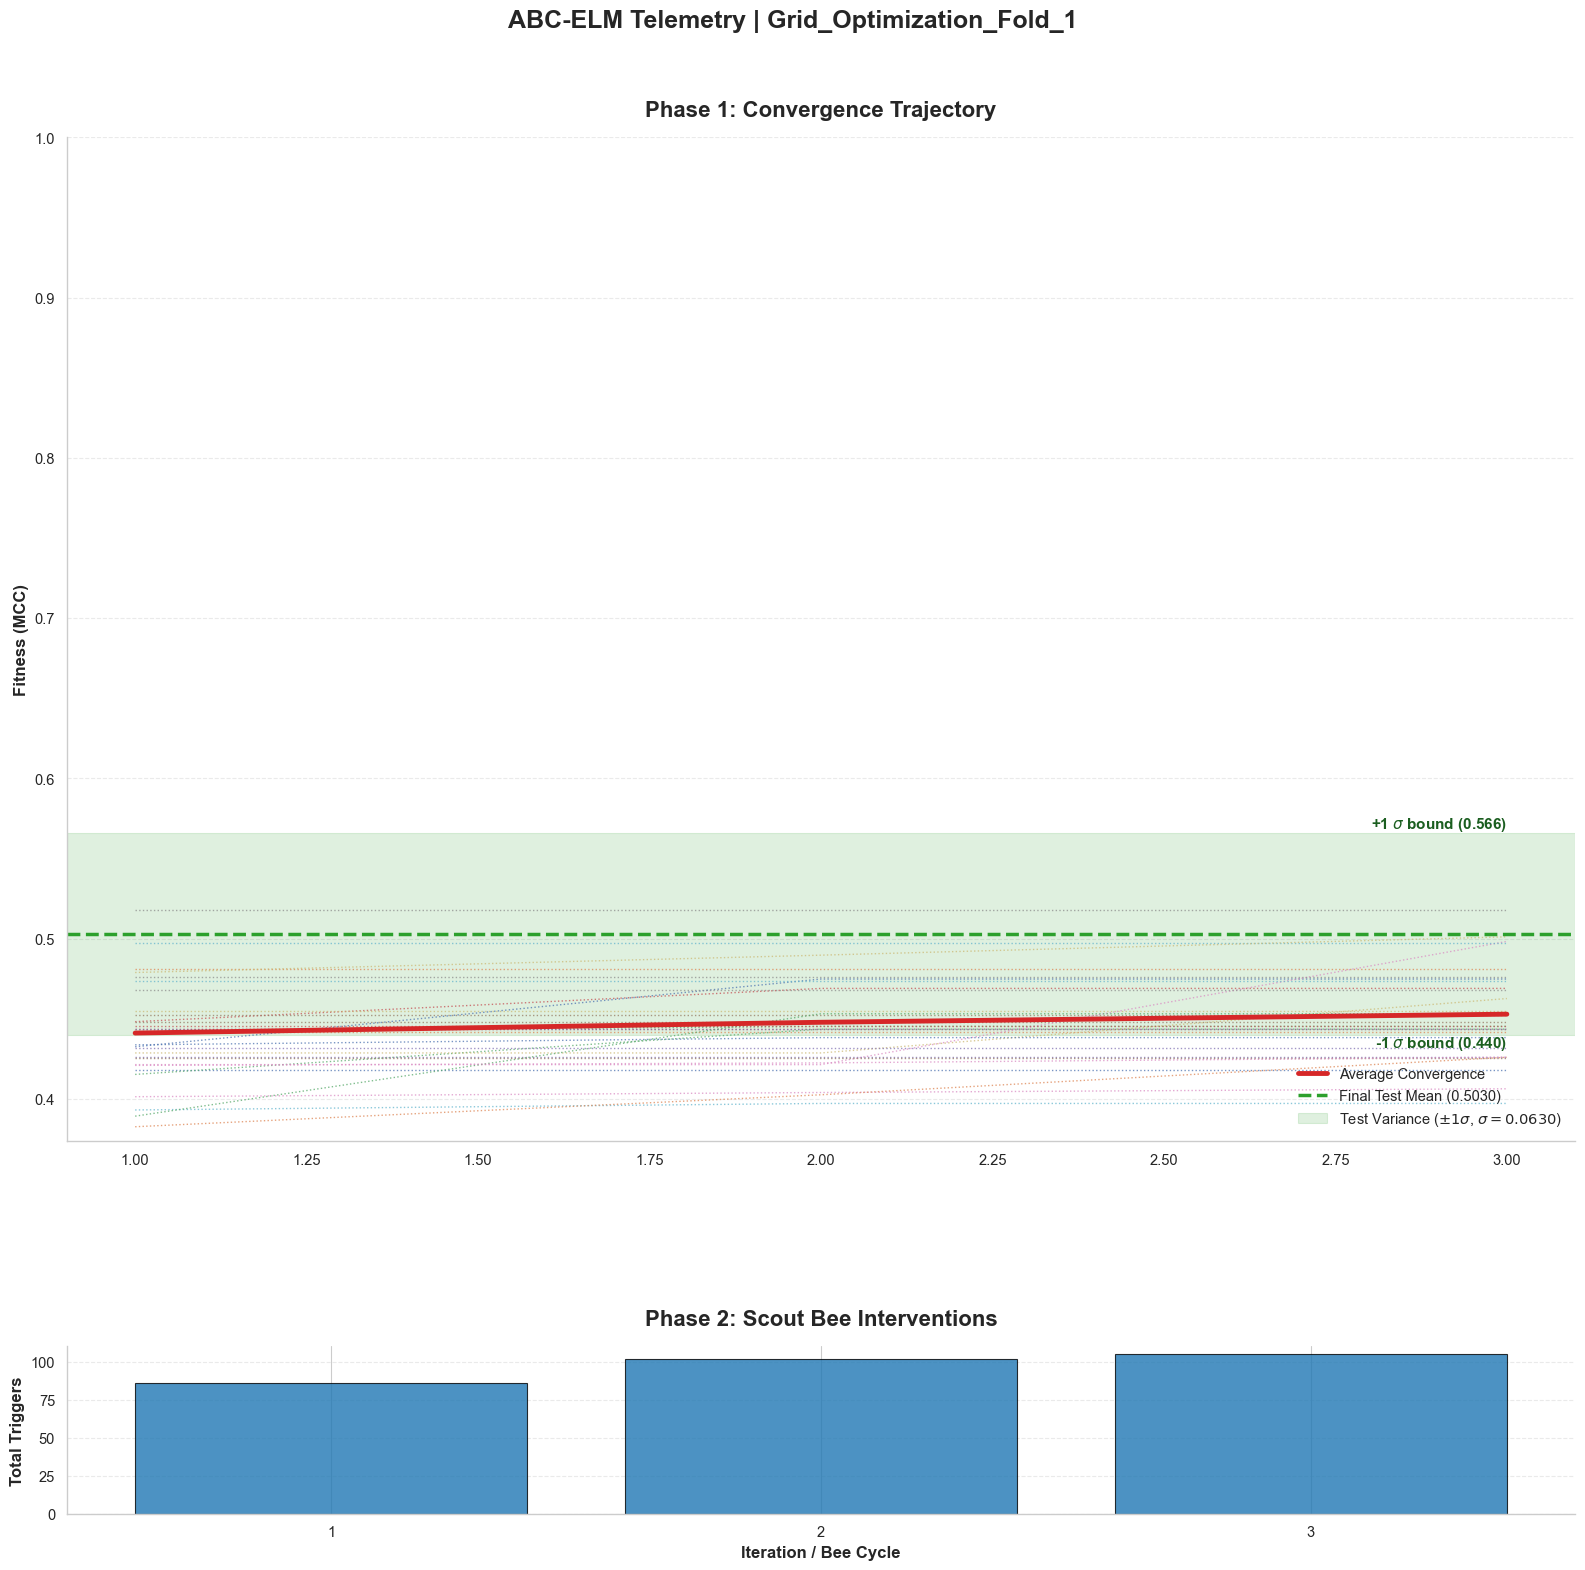

In [13]:
Plotting.plot_abc_dashboard(convergence_df,scout_df,mod,results_df=results_df,is_final_record=True)

In [14]:
GlobalSetting.save_dataframe_to_record(results_df, f"ABC_{mod}_Results.csv")
GlobalSetting.save_dataframe_to_record(convergence_df, f'ABC_{mod}_Convergence.csv')
GlobalSetting.save_dataframe_to_record(scout_df, f'ABC_{mod}_Scout_History.csv')

[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Optimization_Fold_1_Results.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Optimization_Fold_1_Convergence.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Optimization_Fold_1_Scout_History.csv
